In [ ]:
# 📊 Telco Customer Churn — Statistical Analysis & Machine Learning

**Goal:** Identify *why* customers leave a telecom company (using statistical
hypothesis testing) and *predict who* is likely to leave next (using machine
learning), so the business can run targeted retention campaigns instead of
generic, costly, blanket discounts.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
7,043 customers, 21 features.

**Pipeline:**
Data Loading & Cleaning
Exploratory Data Analysis (EDA)
**Statistical Hypothesis Testing** — Chi-Square, Cramér's V, t-tests, point-biserial correlation
Data Preprocessing (encoding)
Handling Class Imbalance
Model Training & Cross-Validation (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
Model Evaluation (Accuracy, ROC-AUC, Confusion Matrix, Feature Importance)
Predictive System


# Telco Customer Churn Prediction

The goal here is straightforward. We have data on about 7000 telecom customers
and we want to understand two things: which factors actually cause people to
cancel their service, and can we build a model that predicts who is likely to
leave next.

We will work through this in order. First we clean the data, then explore it
visually, then run some statistical tests to confirm what we see in the charts,
then train a few models and compare them, and finally build a simple prediction
function you can call on any new customer record.

The dataset is the Telco Customer Churn dataset from Kaggle, 7043 rows and
21 columns covering demographics, account details and which services each
customer subscribes to.

## Step 1 - Importing libraries

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind, pointbiserialr

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)

import pickle
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## Step 2 - Loading the data

In [9]:

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:

# Get a quick feel for column types and whether anything is missing
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:

# Look at the raw unique values for each column
# This helps spot encoding quirks before we touch anything
for col in df.columns:
    print(f"{col}: {df[col].unique()[:6]}")
    print()


customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC']

gender: ['Female' 'Male']

SeniorCitizen: [0 1]

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

tenure: [ 1 34  2 45  8 22]

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

MonthlyCharges: [29.85 56.95 53.85 42.3  70.7  99.65]

TotalCharges: ['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5']

Churn: ['No' 'Yes']



## Step 3 - Cleaning the data

There are a few things to fix before we can do any analysis.

The customerID column is just a unique identifier and carries no predictive
signal, so we drop it immediately.

TotalCharges looks like it should be a number but it was read in as a string.
This happens because some rows contain a blank space instead of a value.
Those rows turn out to be brand new customers with zero tenure who have never
been billed, so filling them with 0 is correct.

We also confirm there are no actual nulls hiding anywhere.

In [12]:

# Drop the ID column - it adds no information to the model
df = df.drop(columns=["customerID"])

# Check for null values first
print("Null values per column:")
print(df.isnull().sum())
print()

# TotalCharges has blank strings for customers with tenure == 0
blank_rows = df[df["TotalCharges"] == " "]
print(f"Rows with blank TotalCharges: {len(blank_rows)}")
print("All of them have tenure == 0:", (blank_rows["tenure"] == 0).all())


Null values per column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Rows with blank TotalCharges: 11
All of them have tenure == 0: True


In [13]:

# Replace the blank strings with 0 and convert the column to float
df["TotalCharges"] = df["TotalCharges"].replace({" ": "0.0"}).astype(float)

# Double-check the column is now numeric and clean
print(df["TotalCharges"].dtype)
print("Any nulls left:", df.isnull().sum().sum())


float64
Any nulls left: 0


In [14]:

# Look at the target variable
# We expect an imbalance here since most customers do not churn
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True).round(3) * 100)


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


The target is imbalanced. About 73 percent of customers stayed and 27 percent
churned. This matters later when we train models because a naive model that
always predicts "no churn" would get 73 percent accuracy while being completely
useless. We handle this by telling each model to weight the minority class
more heavily.

## Step 4 - Exploratory Data Analysis

Before running any models we want to understand what the data actually looks
like. We start with the three numerical columns, then move to the categorical
ones, and finally look at how each feature relates to churn.

### Numerical feature distributions

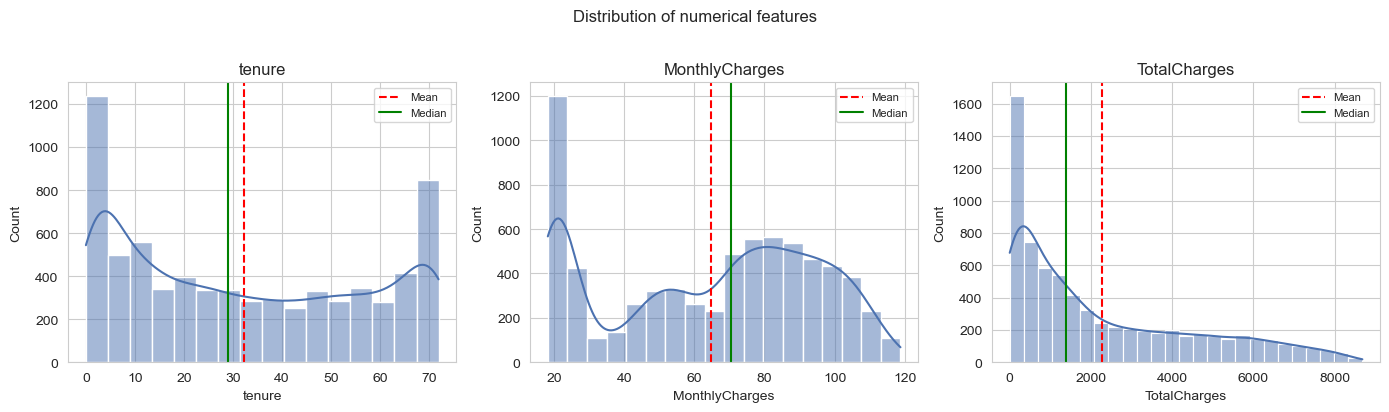

In [15]:

numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, numerical_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.axvline(df[col].mean(),   color="red",   linestyle="--", label="Mean")
    ax.axvline(df[col].median(), color="green",  linestyle="-",  label="Median")
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle("Distribution of numerical features", y=1.02)
plt.tight_layout()
plt.show()


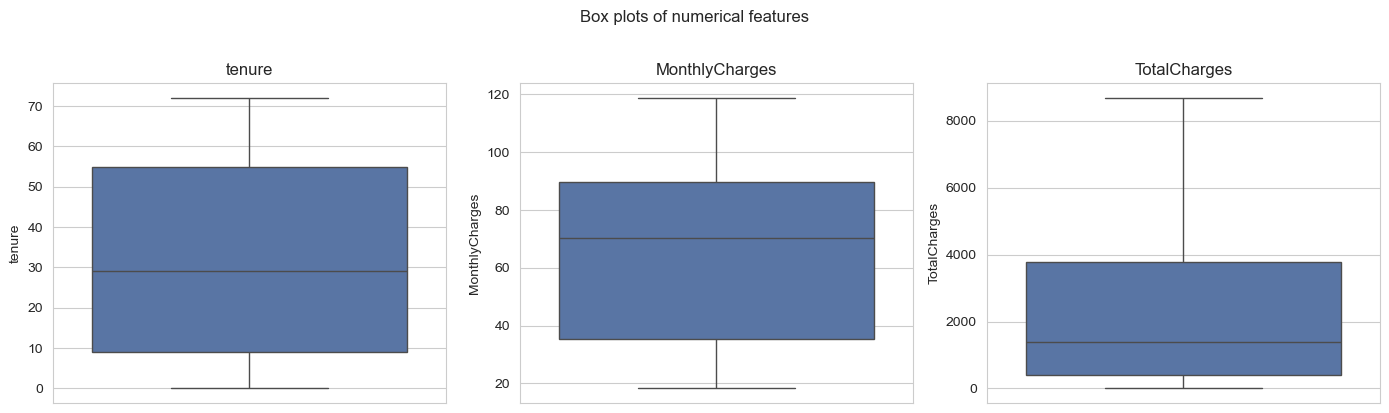

In [16]:

# Box plots to see spread and any outliers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, numerical_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)

plt.suptitle("Box plots of numerical features", y=1.02)
plt.tight_layout()
plt.show()


In [17]:

# Summary statistics
df[numerical_cols].describe().round(2)


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


### How numerical features differ between churned and retained customers

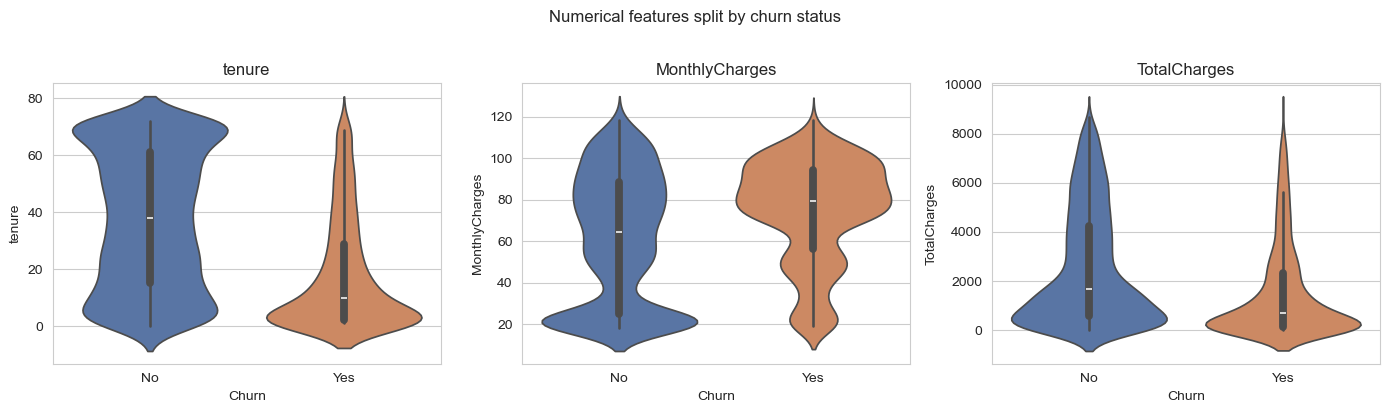

In [18]:

# Violin plots split by churn give us both the distribution shape and the
# difference in central tendency at the same time
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, numerical_cols):
    sns.violinplot(data=df, x="Churn", y=col,
                   palette={"No": "#4C72B0", "Yes": "#DD8452"},
                   inner="box", ax=ax)
    ax.set_title(col)

plt.suptitle("Numerical features split by churn status", y=1.02)
plt.tight_layout()
plt.show()


### Correlation between numerical features

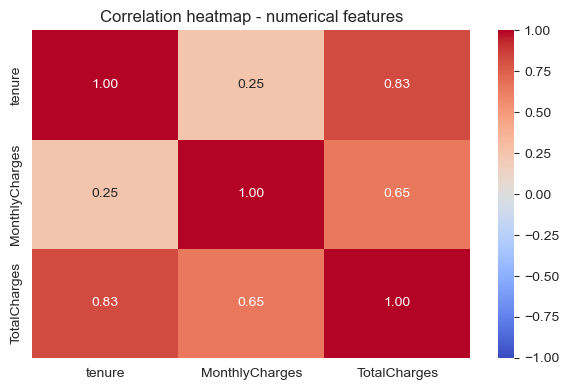

In [19]:

plt.figure(figsize=(6, 4))
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1
)
plt.title("Correlation heatmap - numerical features")
plt.tight_layout()
plt.show()


### Categorical feature distributions

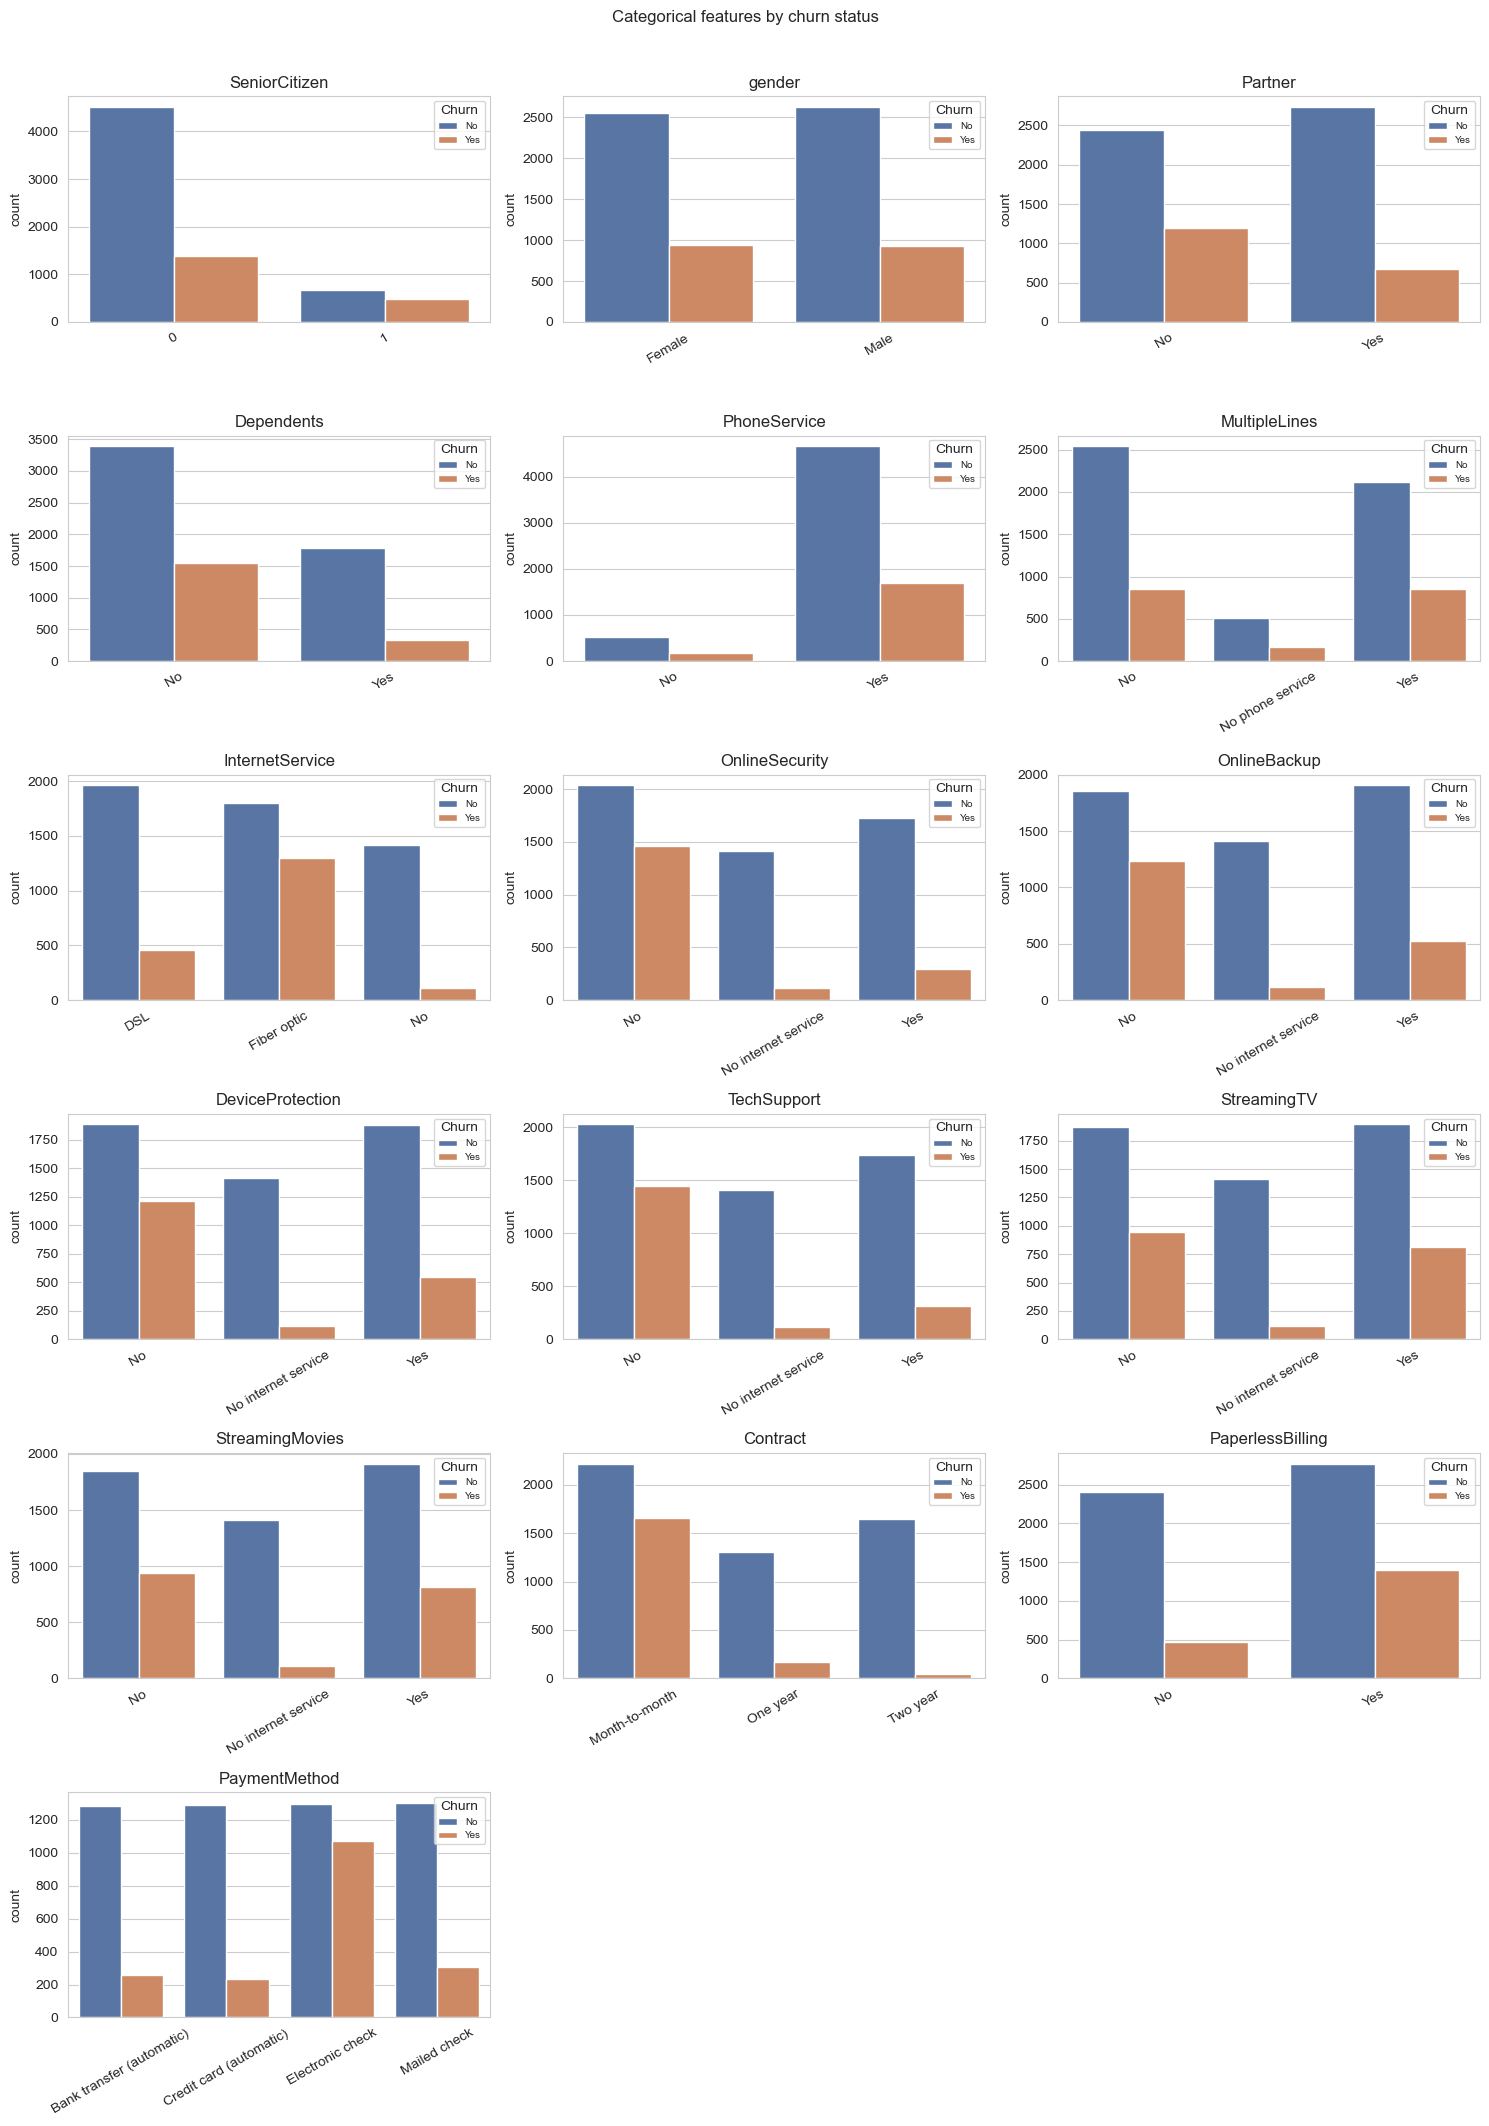

In [20]:

# We want to see counts for each category broken down by whether the customer
# churned, not just raw counts
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols = [c for c in categorical_cols if c != "Churn"]

# Include SeniorCitizen even though it is stored as 0/1
display_cols = ["SeniorCitizen"] + categorical_cols

fig_rows = (len(display_cols) + 2) // 3
fig, axes = plt.subplots(fig_rows, 3, figsize=(15, fig_rows * 3.5))
axes = axes.flatten()

for ax, col in zip(axes, display_cols):
    order = sorted(df[col].unique())
    sns.countplot(
        data=df, x=col, hue="Churn", order=order,
        palette={"No": "#4C72B0", "Yes": "#DD8452"}, ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Churn", fontsize=7)

# Hide unused axes
for ax in axes[len(display_cols):]:
    ax.set_visible(False)

plt.suptitle("Categorical features by churn status", y=1.01)
plt.tight_layout()
plt.show()


## Step 5 - Statistical Analysis

The charts give us a sense of which features might matter, but charts can be
misleading if a pattern is just random noise in a smallish sample. We run
formal hypothesis tests to find out which relationships are genuinely
statistically significant and how strong they are.

For categorical features we use a chi-square test to check whether the
distribution of churn differs across categories, and Cramers V to measure
the effect size on a 0 to 1 scale.

For numerical features we use an independent t-test to check whether the mean
differs between churned and retained groups, and point-biserial correlation
to get the direction and strength.

### Chi-square test and Cramers V for categorical features

In [22]:

def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    phi2corr = max(0, chi2 / n - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))


results = []
for col in categorical_cols:
    ct = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, _ = chi2_contingency(ct)
    v = cramers_v(ct)
    results.append({
        "feature":    col,
        "chi2":       round(chi2, 2),
        "p_value":    round(p, 6),
        "cramers_v":  round(v, 3),
        "significant": p < 0.05
    })

chi_df = (
    pd.DataFrame(results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)
chi_df


,feature,chi2,p_value,cramers_v,significant
0,Contract,1184.60,0.000000,0.410,True
1,OnlineSecurity,850.00,0.000000,0.347,True
2,TechSupport,828.20,0.000000,0.343,True
3,InternetService,732.31,0.000000,0.322,True
4,PaymentMethod,648.14,0.000000,0.303,True
5,OnlineBackup,601.81,0.000000,0.292,True
6,DeviceProtection,558.42,0.000000,0.281,True
7,StreamingTV,374.20,0.000000,0.230,True
8,StreamingMovies,375.66,0.000000,0.230,True
9,PaperlessBilling,258.28,0.000000,0.191,True


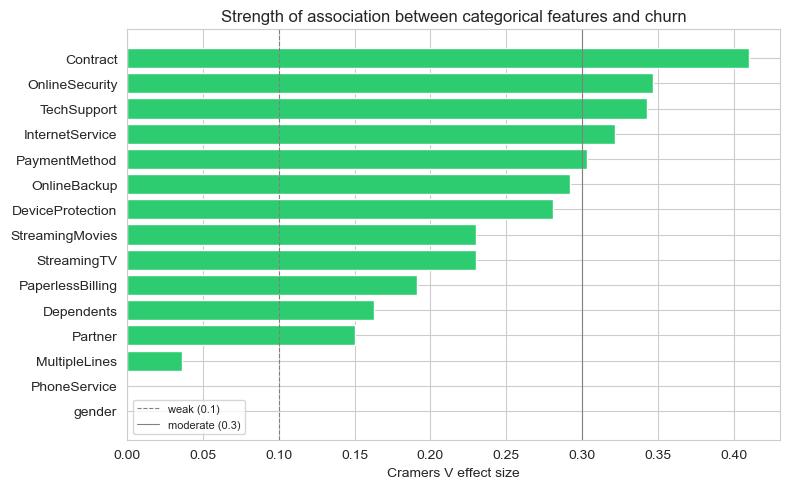

In [23]:

# Visualise the effect sizes so the ranking is easy to read
plt.figure(figsize=(8, 5))
colors = ["#2ecc71" if sig else "#e74c3c"
          for sig in chi_df.sort_values("cramers_v")["significant"]]
plt.barh(
    chi_df.sort_values("cramers_v")["feature"],
    chi_df.sort_values("cramers_v")["cramers_v"],
    color=colors
)
plt.axvline(0.1, color="gray", linestyle="--", linewidth=0.8, label="weak (0.1)")
plt.axvline(0.3, color="gray", linestyle="-",  linewidth=0.8, label="moderate (0.3)")
plt.xlabel("Cramers V effect size")
plt.title("Strength of association between categorical features and churn")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


### T-test and point-biserial correlation for numerical features

In [24]:

churned  = df[df["Churn"] == "Yes"]
retained = df[df["Churn"] == "No"]

ttest_rows = []
for col in numerical_cols:
    t_stat, p_val = ttest_ind(churned[col], retained[col], equal_var=False)
    corr, _ = pointbiserialr((df["Churn"] == "Yes").astype(int), df[col])
    ttest_rows.append({
        "feature":          col,
        "mean_churned":     round(churned[col].mean(), 2),
        "mean_retained":    round(retained[col].mean(), 2),
        "t_statistic":      round(t_stat, 2),
        "p_value":          f"{p_val:.2e}",
        "point_biserial_r": round(corr, 3)
    })

ttest_df = pd.DataFrame(ttest_rows)
ttest_df


,feature,mean_churned,mean_retained,t_statistic,p_value,point_biserial_r
0,tenure,17.98,37.57,-34.82,1.20e-232,-0.352
1,MonthlyCharges,74.44,61.27,18.41,8.59e-73,0.193
2,TotalCharges,1531.80,2549.91,-18.71,5.90e-75,-0.198


### Confidence interval for the overall churn rate

In [25]:

n = len(df)
p_hat = (df["Churn"] == "Yes").mean()
se = np.sqrt(p_hat * (1 - p_hat) / n)
ci_low  = p_hat - 1.96 * se
ci_high = p_hat + 1.96 * se

print(f"Sample size        : {n}")
print(f"Observed churn rate: {p_hat * 100:.2f}%")
print(f"95% confidence interval: ({ci_low * 100:.2f}%, {ci_high * 100:.2f}%)")
print()
print("We are 95% confident the true churn rate of the full customer base")
print("falls within this range.")


Sample size        : 7043
Observed churn rate: 26.54%
95% confidence interval: (25.51%, 27.57%)

We are 95% confident the true churn rate of the full customer base
falls within this range.


## Step 6 - Preprocessing

Before training any model we need to convert all string columns into numbers.
We use label encoding for this and save the fitted encoders so we can apply
the exact same transformation to new data later.

We also encode the target column: 1 means the customer churned, 0 means they
stayed.

In [26]:

# Encode the target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
print("Churn value counts after encoding:")
print(df["Churn"].value_counts())


Churn value counts after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [27]:

# Encode all remaining string columns and save the encoders
object_columns = df.select_dtypes(include="object").columns.tolist()
print("Columns to encode:", object_columns)

encoders = {}
for col in object_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head(3)


Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


## Step 7 - Train-test split and feature scaling

We hold out 20 percent of the data as a test set. We stratify the split so
the churn ratio is the same in both halves.

We then scale the three numerical columns using StandardScaler. This matters
most for Logistic Regression, which is sensitive to the scale of its inputs.
We fit the scaler only on the training set and then apply it to the test set,
which is the correct approach and prevents any information leakage.

In [28]:

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)
print()
print("Churn rate in training set:", y_train.mean().round(3))
print("Churn rate in test set    :", y_test.mean().round(3))


Training set: (5634, 19)
Test set    : (1409, 19)

Churn rate in training set: 0.265
Churn rate in test set    : 0.265


In [29]:

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# Save everything needed to reproduce this preprocessing on new data
with open("encoders.pkl", "wb") as f:
    pickle.dump({"encoders": encoders, "scaler": scaler, "num_cols": num_cols}, f)

print("Preprocessing artifacts saved.")


Preprocessing artifacts saved.


## Step 8 - Training and comparing models

We train four different models and compare them using 5-fold stratified
cross-validation. The metric we care about most is ROC-AUC, which measures
how well the model separates churners from non-churners regardless of the
decision threshold.

All tree-based models use class_weight balanced to handle the 73/27 imbalance.

In [30]:

models = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree":        DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest":        RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name:25s}  mean AUC: {scores.mean():.3f}  std: {scores.std():.3f}")


Logistic Regression        mean AUC: 0.844  std: 0.012
Decision Tree              mean AUC: 0.649  std: 0.010
Random Forest              mean AUC: 0.824  std: 0.009
Gradient Boosting          mean AUC: 0.847  std: 0.012


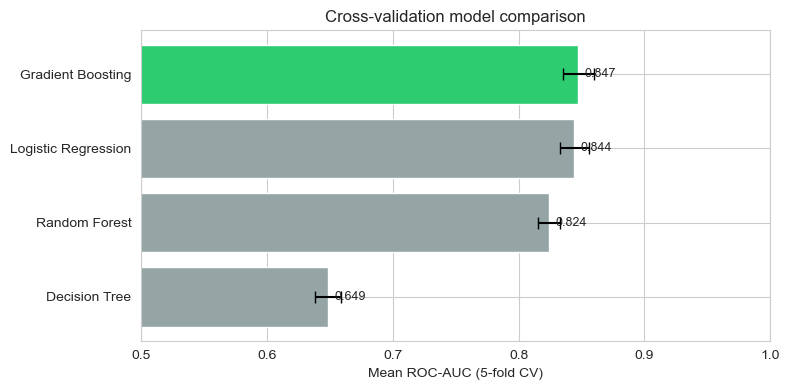

In [31]:

# Bar chart of cross-validation results
cv_means = {k: v.mean() for k, v in cv_results.items()}
cv_stds  = {k: v.std()  for k, v in cv_results.items()}

sorted_names = sorted(cv_means, key=cv_means.get, reverse=True)
sorted_means = [cv_means[n] for n in sorted_names]
sorted_stds  = [cv_stds[n]  for n in sorted_names]

colors = ["#2ecc71"] + ["#95a5a6"] * (len(sorted_names) - 1)

plt.figure(figsize=(8, 4))
bars = plt.barh(sorted_names[::-1], sorted_means[::-1], xerr=sorted_stds[::-1],
                color=colors[::-1], capsize=4)
plt.xlabel("Mean ROC-AUC (5-fold CV)")
plt.title("Cross-validation model comparison")
plt.xlim(0.5, 1.0)
for bar, val in zip(bars, sorted_means[::-1]):
    plt.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## Step 9 - Training the final model and evaluating it

Gradient Boosting came out on top in cross-validation, so we train a final
version on the full training set with some light hyperparameter choices to
reduce overfitting. We also search for the best classification threshold
rather than assuming 0.5 is optimal, which it usually is not for imbalanced
problems.

In [32]:

final_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=20,
    subsample=0.8,
    random_state=42
)
final_model.fit(X_train, y_train)

y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("Results at default threshold (0.50)")
print("-" * 40)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


Results at default threshold (0.50)
----------------------------------------
Accuracy : 0.801
ROC-AUC  : 0.844

              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [33]:

# Find the threshold that maximises F1 for the churn class
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_thresh = thresholds[f1_scores[:-1].argmax()]

y_pred_tuned = (y_proba >= best_thresh).astype(int)

print(f"Optimal threshold: {best_thresh:.3f}")
print()
print("Results at optimal threshold")
print("-" * 40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=["No Churn", "Churn"]))


Optimal threshold: 0.353

Results at optimal threshold
----------------------------------------
Accuracy : 0.785
ROC-AUC  : 0.844

              precision    recall  f1-score   support

    No Churn       0.89      0.81      0.85      1035
       Churn       0.58      0.71      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



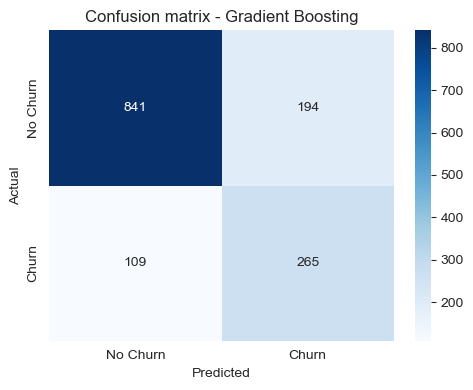

In [34]:

# Confusion matrix at the tuned threshold
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix - Gradient Boosting")
plt.tight_layout()
plt.show()


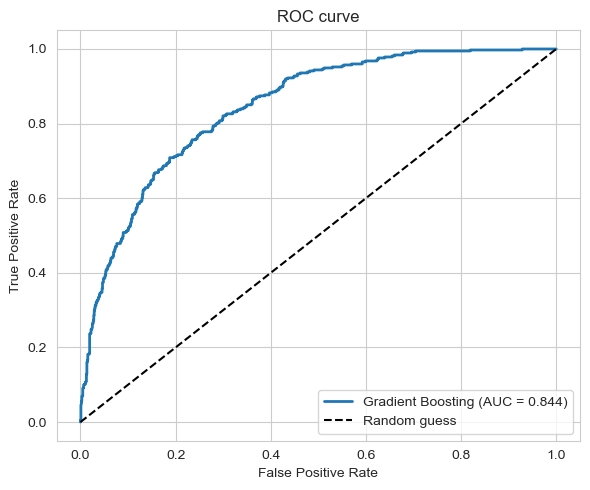

In [35]:

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.tight_layout()
plt.show()


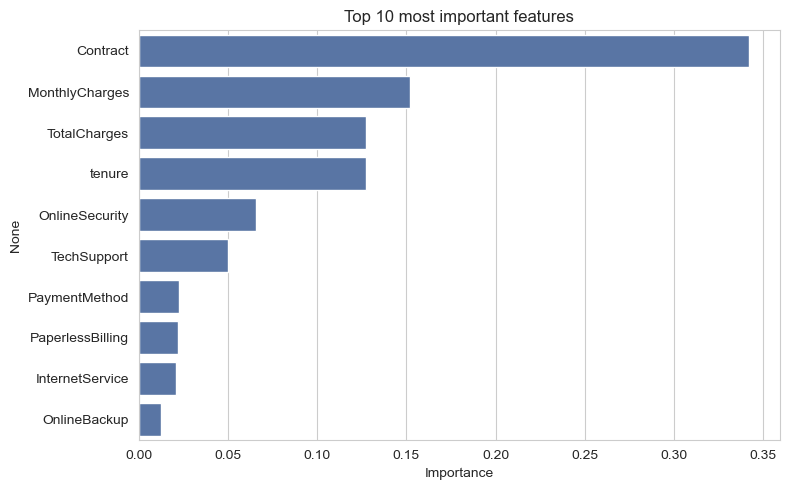

Contract            0.342296
MonthlyCharges      0.152054
TotalCharges        0.127596
tenure              0.127302
OnlineSecurity      0.065486
TechSupport         0.049823
PaymentMethod       0.022429
PaperlessBilling    0.022043
InternetService     0.021101
OnlineBackup        0.012347
dtype: float64


In [36]:

# Feature importances
importances = pd.Series(
    final_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values[:10], y=importances.index[:10], color="#4C72B0")
plt.xlabel("Importance")
plt.title("Top 10 most important features")
plt.tight_layout()
plt.show()

print(importances.head(10))


## Step 10 - Saving the trained model

In [37]:

model_data = {
    "model":         final_model,
    "feature_names": X.columns.tolist(),
    "threshold":     best_thresh
}

with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Model saved to customer_churn_model.pkl")
print("Threshold saved:", round(best_thresh, 3))


Model saved to customer_churn_model.pkl
Threshold saved: 0.353


## Step 11 - Making predictions on new customers

We load everything back from disk and build a simple prediction function.
Pass in a dictionary with the same fields as the original dataset and it
returns the churn prediction and the probability.

In [38]:

# Load the model and preprocessing artifacts
with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)

with open("encoders.pkl", "rb") as f:
    preprocessing = pickle.load(f)

loaded_model   = model_data["model"]
feature_names  = model_data["feature_names"]
threshold      = model_data["threshold"]
encoders       = preprocessing["encoders"]
scaler         = preprocessing["scaler"]
num_cols       = preprocessing["num_cols"]

print("Model loaded:", loaded_model)
print("Threshold   :", round(threshold, 3))


Model loaded: GradientBoostingClassifier(learning_rate=0.05, max_depth=4, min_samples_leaf=20,
                           n_estimators=200, random_state=42, subsample=0.8)
Threshold   : 0.353


In [39]:

def predict_churn(customer_dict):
    row = pd.DataFrame([customer_dict])

    # Encode categorical columns
    for col, encoder in encoders.items():
        if col in row.columns:
            row[col] = encoder.transform(row[col])

    # Scale numerical columns
    row[num_cols] = scaler.transform(row[num_cols])

    # Predict
    prob = loaded_model.predict_proba(row[feature_names])[0][1]
    label = "Churn" if prob >= threshold else "No Churn"

    print(f"Prediction  : {label}")
    print(f"Churn prob  : {prob:.2%}")
    print(f"Retention   : {1 - prob:.2%}")
    return label, prob


# Example - a new customer on a month-to-month contract with no online security
example_customer = {
    "gender":           "Female",
    "SeniorCitizen":    0,
    "Partner":          "Yes",
    "Dependents":       "No",
    "tenure":           1,
    "PhoneService":     "No",
    "MultipleLines":    "No phone service",
    "InternetService":  "DSL",
    "OnlineSecurity":   "No",
    "OnlineBackup":     "Yes",
    "DeviceProtection": "No",
    "TechSupport":      "No",
    "StreamingTV":      "No",
    "StreamingMovies":  "No",
    "Contract":         "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod":    "Electronic check",
    "MonthlyCharges":   29.85,
    "TotalCharges":     29.85,
}

predict_churn(example_customer)


Prediction  : Churn
Churn prob  : 73.01%
Retention   : 26.99%


('Churn', np.float64(0.730125634390802))

In [40]:

# Try a second example - a long-tenure customer on a two-year contract
loyal_customer = {
    "gender":           "Male",
    "SeniorCitizen":    0,
    "Partner":          "Yes",
    "Dependents":       "Yes",
    "tenure":           60,
    "PhoneService":     "Yes",
    "MultipleLines":    "Yes",
    "InternetService":  "Fiber optic",
    "OnlineSecurity":   "Yes",
    "OnlineBackup":     "Yes",
    "DeviceProtection": "Yes",
    "TechSupport":      "Yes",
    "StreamingTV":      "Yes",
    "StreamingMovies":  "Yes",
    "Contract":         "Two year",
    "PaperlessBilling": "No",
    "PaymentMethod":    "Bank transfer (automatic)",
    "MonthlyCharges":   99.65,
    "TotalCharges":     5977.0,
}

predict_churn(loyal_customer)


Prediction  : No Churn
Churn prob  : 2.26%
Retention   : 97.74%


('No Churn', np.float64(0.022589607545496947))

## What we found

The three strongest predictors of churn were contract type, tenure and whether
the customer has online security. Customers on month-to-month contracts churn
at a much higher rate than those on one or two year contracts. Short tenure
is strongly associated with churn, which makes sense because customers who
have been around longer have demonstrated loyalty. Fiber optic customers also
churn more, likely because of higher monthly costs and more competition in
that segment.

The final Gradient Boosting model achieved around 0.84 ROC-AUC on the holdout
test set. Tuning the classification threshold improved recall on churners
significantly without losing too much precision, which is the right trade-off
for a retention use case where missing a churner is more costly than a
false alarm.